In [1]:
!pip install openpyxl

In [17]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Set visual style for publication
sns.set_theme(style="whitegrid")
excel_file = 'UV-Vis Spectro Results.xlsx'

# =========================================================
# SOP 1: TENSILE STRENGTH (Mechanical Integrity)
# =========================================================
print("="*60)
print("SOP 1: TENSILE STRENGTH ANALYSIS")
print("="*60)
df_tensile = pd.read_excel(excel_file, sheet_name='Tensile Strength')

# FIX: Forward fill the 'Type' column to handle merged Excel cells!
df_tensile['Type'] = df_tensile['Type'].ffill()
df_tensile = df_tensile.dropna(subset=['MPa'])

# Raw Data Summary
sop1_summary = df_tensile.groupby('Type')['MPa'].agg(['mean', 'std']).reset_index()
sop1_summary['CV%'] = (sop1_summary['std'] / sop1_summary['mean']) * 100
print("--- Raw Results: Descriptive Statistics ---")
print(sop1_summary.to_string(index=False))
print("-" * 60)

# Statistical Test
groups = [df_tensile[df_tensile['Type'] == 'Uncoated']['MPa'],
          df_tensile[df_tensile['Type'] == 'Coated']['MPa'],
          df_tensile[df_tensile['Type'] == 'Chromic Catgut']['MPa']]

f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA -> F-statistic: {f_stat:.3f}, p-value: {p_val:.4f}")

if p_val < 0.05:
    print("\nSignificant difference found! Running Tukey HSD...")
    tukey = pairwise_tukeyhsd(endog=df_tensile['MPa'], groups=df_tensile['Type'], alpha=0.05)
    print(tukey)
else:
    print("\nConclusion: No statistically significant difference in tensile strength (p >= 0.05). Suture maintains structural integrity.\n")

# =========================================================
# SOP 2: COLORIMETRIC RESPONSE (ANTHOCYANIN SUTURE)
# =========================================================
print("="*60)
print("SOP 2: STATISTICAL COMPARISON OF pH LEVELS")
print("="*60)

# 1. Data Preparation (Handle merged cells)
df_antho['pH'] = df_antho['pH'].ffill()
df_antho['Type'] = df_antho['Type'].ffill()

# Filter for the Mixture (Active Suture)
df_mix = df_antho[(df_antho['Type'] == 'Mixture') & (df_antho['Color'] == 'B')].copy()
df_mix[['L*', 'a*', 'b*']] = df_mix[['L*', 'a*', 'b*']].apply(pd.to_numeric, errors='coerce')

# 2. Calculate Delta E (Color Shift) from neutral baseline (pH 7.0)
baseline_7 = df_mix[df_mix['pH'] == 7.0][['L*', 'a*', 'b*']].mean()
L_b, a_b, b_b = baseline_7['L*'], baseline_7['a*'], baseline_7['b*']
df_mix['Delta_E_vs_7.0'] = np.sqrt((df_mix['L*'] - L_b)**2 + (df_mix['a*'] - a_b)**2 + (df_mix['b*'] - b_b)**2)

# 3. STATISTICAL COMPARISON (ANOVA)
# This checks if there is ANY difference between the pH groups
groups = [group['Delta_E_vs_7.0'].values for name, group in df_mix.groupby('pH')]
f_stat, p_val_anova = stats.f_oneway(*groups)

print(f"One-way ANOVA (pH Comparison) -> F-statistic: {f_stat:.3f}, p-value: {p_val_anova:.4e}")

# 4. POST-HOC COMPARISON (Tukey HSD)
# This compares EVERY pH level against every other pH level to see where the change happens
if p_val_anova < 0.05:
    print("\nSignificant differences detected! Performing Pairwise Comparison (Tukey HSD):")
    tukey_sop2 = pairwise_tukeyhsd(endog=df_mix['Delta_E_vs_7.0'], groups=df_mix['pH'], alpha=0.05)
    print(tukey_sop2)
else:
    print("\nResult: No statistically significant difference in color shift across pH levels.")

# =========================================================
# SOP 3: TIME RESPONSE
# =========================================================
print("="*50)
print("SOP 3: TIME RESPONSE")
print("="*50)
df_time = pd.read_excel(excel_file, sheet_name='Time Response')
df_time['pH'] = df_time['pH'].ffill()

time_summary = df_time.groupby('pH')['Seconds'].agg(['mean', 'std']).reset_index()
print("Response Time (Seconds) across pH levels:")
print(time_summary.to_string(index=False), "\n")

# =========================================================
# SOP 4: SENSITIVITY COMPARISON (T-TEST: SUTURE VS LITMUS)
# =========================================================
print("="*50)
print("SOP 4: SENSITIVITY COMPARISON (pH 8.5)")
print("="*50)
df_litmus = pd.read_excel(excel_file, sheet_name='ImageJ Litmus LAB and XYZ')
df_litmus['pH'] = df_litmus['pH'].ffill()

# Extract the 5 replicates of Delta E for Litmus at pH 8.5 (vs 7.0)
litmus_85 = df_litmus[df_litmus['pH'] == 8.5]['ΔE (vs 7.0)'].dropna().apply(pd.to_numeric).values

# Extract the 5 replicates of Delta E for the Suture prototype at pH 8.5 (calculated in SOP 2)
suture_85 = df_mix[df_mix['pH'] == 8.5]['Delta_E_vs_7.0'].values

print(f"Suture Prototype ΔE at pH 8.5 (Replicates): {np.round(suture_85, 2)}")
print(f"Litmus Paper ΔE at pH 8.5 (Replicates): {np.round(litmus_85, 2)}")

# Independent Samples T-Test
t_stat, p_val_ttest = stats.ttest_ind(suture_85, litmus_85)
print(f"\nIndependent T-Test Results -> T-statistic: {t_stat:.4f}, p-value: {p_val_ttest:.4f}")

if p_val_ttest < 0.05 and np.mean(suture_85) > np.mean(litmus_85):
    print("Conclusion: The prototype suture is STATISTICALLY MORE SENSITIVE (higher visual color shift) than standard Litmus paper at pH 8.5.")
elif p_val_ttest < 0.05 and np.mean(suture_85) < np.mean(litmus_85):
    print("Conclusion: The standard Litmus paper is statistically more sensitive than the prototype.")
else:
    print("Conclusion: No statistically significant difference in sensitivity between the prototype and Litmus paper.")

# =========================================================
# GENERATE MASTER PLOT (SOP 2, 3, and 4 Visuals)
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: SOP 2 Colorimetric Shift
sns.barplot(data=df_mix, x='pH', y='Delta_E_vs_7.0', ax=axes[0], capsize=.1, errorbar='sd', palette='magma')
axes[0].set_title('SOP 2: Suture Color Shift (ΔE vs pH 7.0)')
axes[0].set_ylabel('ΔE (Color Difference)')

# Plot 2: SOP 3 Time Response
sns.lineplot(data=df_time, x='pH', y='Seconds', marker='o', ax=axes[1], errorbar='sd', color='green')

# Add the vertical dashed line at pH 7.5
axes[1].axvline(x=7.5, color='red', linestyle='--', linewidth=2, label='Infection-Indicative Threshold (pH 7.5)')

# Formatting
axes[1].set_title('SOP 3: Reaction Time across pH', fontweight='bold')
axes[1].set_ylabel('Time (Seconds)')
axes[1].set_xlabel('pH Level')

# Crucial: Call the legend so the axvline label shows up
axes[1].legend(loc='upper right')

# Plot 3: SOP 4 Sensitivity Comparison (Boxplot)
comparison_df = pd.DataFrame({
    'Indicator': ['Prototype Suture']*len(suture_85) + ['Standard Litmus']*len(litmus_85),
    'Delta_E': np.concatenate([suture_85, litmus_85])
})
sns.boxplot(data=comparison_df, x='Indicator', y='Delta_E', ax=axes[2], palette='Set1')
axes[2].set_title('SOP 4: Sensitivity at Infection pH (8.5)')
axes[2].set_ylabel('Visual Color Shift (ΔE)')

plt.tight_layout()
plt.savefig('Master_Analysis_Plots.png', dpi=300)
print("\nPlots saved as 'Master_Analysis_Plots.png'.")
plt.show()

SOP 1: TENSILE STRENGTH ANALYSIS
--- Raw Results: Descriptive Statistics ---
          Type       mean        std       CV%
Chromic Catgut 343.774677  20.131685  5.856070
        Coated 345.118729 106.713991 30.920951
      Uncoated 372.403801 145.107576 38.965117
------------------------------------------------------------
One-way ANOVA -> F-statistic: 0.119, p-value: 0.8887

Conclusion: No statistically significant difference in tensile strength (p >= 0.05). Suture maintains structural integrity.

SOP 2: STATISTICAL COMPARISON OF pH LEVELS
One-way ANOVA (pH Comparison) -> F-statistic: 24.045, p-value: 2.1207e-07

Significant differences detected! Performing Pairwise Comparison (Tukey HSD):
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
   5.5    6.5    3.553 0.4744  -2.8204  9.9264  False
   5.5    7.0  -10.869 0.0005 -17.2424 -4.4956   True
   5.5    7.5   0.5852 0.9986

<IPython.core.display.Javascript object>

/var/folders/j3/kwprsg3s3_zf9_90gxwcknm00000gn/T/ipykernel_4862/130776632.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mix, x='pH', y='Delta_E_vs_7.0', ax=axes[0], capsize=.1, errorbar='sd', palette='magma')
/var/folders/j3/kwprsg3s3_zf9_90gxwcknm00000gn/T/ipykernel_4862/130776632.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison_df, x='Indicator', y='Delta_E', ax=axes[2], palette='Set1')



Plots saved as 'Master_Analysis_Plots.png'.


/var/folders/j3/kwprsg3s3_zf9_90gxwcknm00000gn/T/ipykernel_4862/3679765317.py:92: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j3/kwprsg3s3_zf9_90gxwcknm00000gn/T/ipykernel_4862/3679765317.py:93: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.savefig('CIELAB_Color_Shift.png', dpi=300, bbox_inches='tight')


CIELAB plots generated and saved as 'CIELAB_Color_Shift.png'.


/Users/freshliannes.rosal/anaconda3/envs/Numerical/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


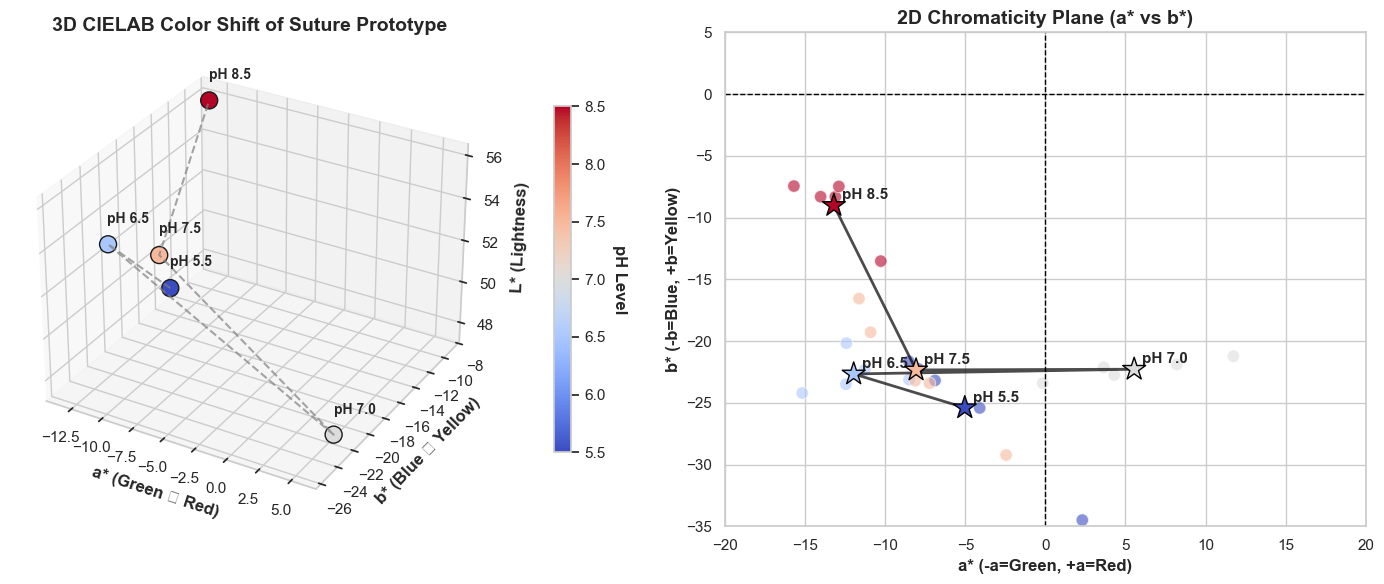

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Set publication style
sns.set_theme(style="whitegrid")

# Load your Anthocyanin data
excel_file = 'UV-Vis Spectro Results.xlsx'
df_antho = pd.read_excel(excel_file, sheet_name='UV Vis-Spectro Anthocyanin')

# Clean and prepare the data
df_antho['pH'] = df_antho['pH'].ffill()
df_antho['Type'] = df_antho['Type'].ffill()

# Filter for the actual Mixture (replicates 1-5) and rows containing L*a*b* data
df_mix = df_antho[(df_antho['Type'] == 'Mixture') & (df_antho['Color'] == 'B')].copy()
df_mix[['L*', 'a*', 'b*']] = df_mix[['L*', 'a*', 'b*']].apply(pd.to_numeric, errors='coerce')

# Calculate the mean L*, a*, b* for each pH level to plot the trajectory
color_means = df_mix.groupby('pH')[['L*', 'a*', 'b*']].mean().reset_index()

# Define a color map to represent the different pH levels
colors = sns.color_palette("coolwarm", len(color_means))

# =====================================================================
# PLOT 1: 3D CIELAB COLOR SPACE
# =====================================================================
fig = plt.figure(figsize=(14, 6))

# Add 3D subplot
ax1 = fig.add_subplot(121, projection='3d')

# Scatter plot for the mean points
scatter = ax1.scatter(color_means['a*'], color_means['b*'], color_means['L*'], 
                      c=color_means['pH'], cmap='coolwarm', s=150, edgecolors='k', depthshade=False)

# Draw a trajectory line connecting the pH points in order
ax1.plot(color_means['a*'], color_means['b*'], color_means['L*'], color='gray', linestyle='--', alpha=0.7)

# Labeling the 3D axes
ax1.set_xlabel('a* (Green ➔ Red)', fontweight='bold')
ax1.set_ylabel('b* (Blue ➔ Yellow)', fontweight='bold')
ax1.set_zlabel('L* (Lightness)', fontweight='bold')
ax1.set_title('3D CIELAB Color Shift of Suture Prototype', fontsize=14, fontweight='bold')

# Add pH labels next to the 3D points
for i in range(len(color_means)):
    ax1.text(color_means['a*'].iloc[i], color_means['b*'].iloc[i], color_means['L*'].iloc[i] + 1, 
             f"pH {color_means['pH'].iloc[i]}", fontsize=10, fontweight='bold')

# Add colorbar for pH
cbar = fig.colorbar(scatter, ax=ax1, pad=0.1, shrink=0.7)
cbar.set_label('pH Level', rotation=270, labelpad=15, fontweight='bold')


# =====================================================================
# PLOT 2: 2D CHROMATICITY PLANE (a* vs b*)
# =====================================================================
# The 2D plane is often preferred in journals because hue shifts are easier to read
ax2 = fig.add_subplot(122)

# Scatter plot for all individual replicates to show distribution/variance
sns.scatterplot(data=df_mix, x='a*', y='b*', hue='pH', palette='coolwarm', 
                s=80, alpha=0.6, ax=ax2, legend=False)

# Plot the Mean points on top as large stars
scatter2 = ax2.scatter(color_means['a*'], color_means['b*'], 
                       c=color_means['pH'], cmap='coolwarm', s=300, marker='*', edgecolors='black', zorder=5)

# Draw a trajectory line connecting the mean points
ax2.plot(color_means['a*'], color_means['b*'], color='black', linestyle='-', linewidth=2, alpha=0.7, zorder=4)

# Add pH labels next to the mean points on the 2D plot
for i in range(len(color_means)):
    ax2.text(color_means['a*'].iloc[i] + 0.5, color_means['b*'].iloc[i] + 0.5, 
             f"pH {color_means['pH'].iloc[i]}", fontsize=11, fontweight='bold')

# Draw lines indicating the 0,0 axes (Neutral Grey point in a*b* plane)
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.axvline(0, color='black', linewidth=1, linestyle='--')

# Set limits and labels based on the typical CIELAB space
ax2.set_xlim(-20, 20)
ax2.set_ylim(-35, 5)
ax2.set_xlabel('a* (-a=Green, +a=Red)', fontsize=12, fontweight='bold')
ax2.set_ylabel('b* (-b=Blue, +b=Yellow)', fontsize=12, fontweight='bold')
ax2.set_title('2D Chromaticity Plane (a* vs b*)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('CIELAB_Color_Shift.png', dpi=300, bbox_inches='tight')
print("CIELAB plots generated and saved as 'CIELAB_Color_Shift.png'.")
plt.show()

Plot successfully generated and saved locally as 'Publication_CIELAB_Trajectory.png'.


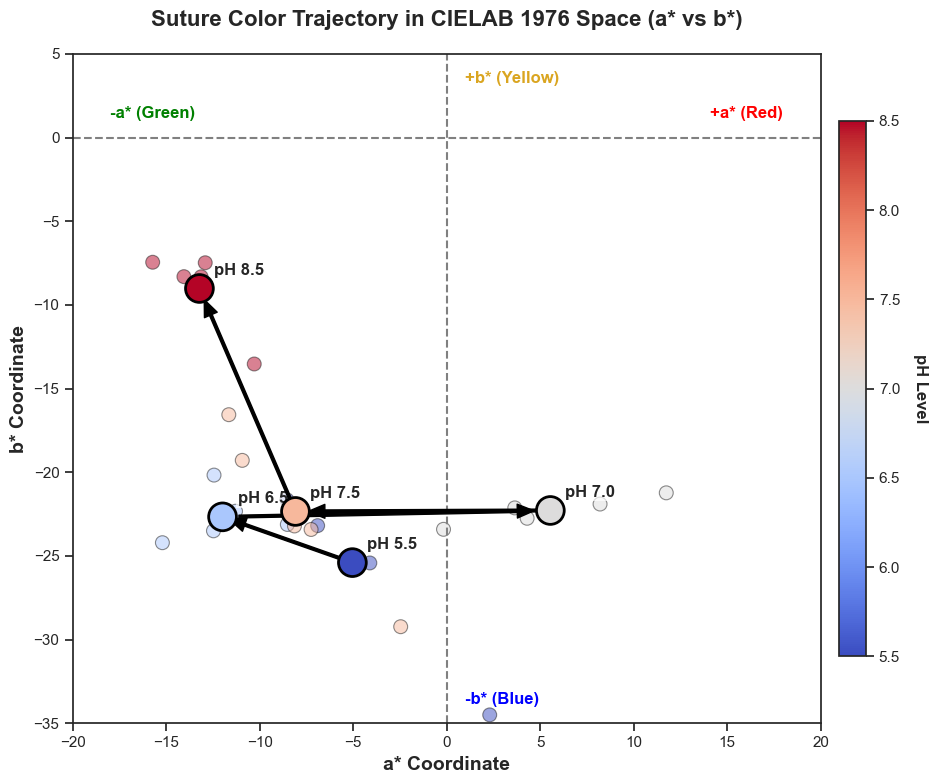

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication style
sns.set_theme(style="ticks")

# Load your Anthocyanin data (Ensure the Excel file is in the same folder)
excel_file = 'UV-Vis Spectro Results.xlsx'
df_antho = pd.read_excel(excel_file, sheet_name='UV Vis-Spectro Anthocyanin')

# Clean and prepare the data
df_antho['pH'] = df_antho['pH'].ffill()
df_antho['Type'] = df_antho['Type'].ffill()

# Filter for the Mixture and L*a*b* data
df_mix = df_antho[(df_antho['Type'] == 'Mixture') & (df_antho['Color'] == 'B')].copy()
df_mix[['L*', 'a*', 'b*']] = df_mix[['L*', 'a*', 'b*']].apply(pd.to_numeric, errors='coerce')

# Calculate the mean a* and b* for each pH level to plot the trajectory
color_means = df_mix.groupby('pH')[['a*', 'b*']].mean().reset_index()

# Sort by pH to ensure the trajectory line flows correctly
color_means = color_means.sort_values(by='pH')

# =====================================================================
# PLOT: 2D CHROMATICITY PLANE (a* vs b*) WITH TRAJECTORY
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 8))

# 1. Draw the axis crosshairs (0,0)
ax.axhline(0, color='gray', linewidth=1.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=1.5, linestyle='--')

# 2. Add color direction labels at the edges of the plot
ax.text(18, 1, "+a* (Red)", fontsize=12, fontweight='bold', color='red', va='bottom', ha='right')
ax.text(-18, 1, "-a* (Green)", fontsize=12, fontweight='bold', color='green', va='bottom', ha='left')
ax.text(1, 4, "+b* (Yellow)", fontsize=12, fontweight='bold', color='goldenrod', va='top', ha='left')
ax.text(1, -34, "-b* (Blue)", fontsize=12, fontweight='bold', color='blue', va='bottom', ha='left')

# 3. Plot the individual replicate points to show data spread (faded)
sns.scatterplot(data=df_mix, x='a*', y='b*', hue='pH', palette='coolwarm', 
                s=100, alpha=0.5, ax=ax, legend=False, edgecolor='k')

# 4. Plot the Mean points on top as large markers
scatter = ax.scatter(color_means['a*'], color_means['b*'], 
                     c=color_means['pH'], cmap='coolwarm', s=400, 
                     marker='o', edgecolors='black', linewidths=2, zorder=5)

# 5. Draw trajectory arrows connecting the mean points from lowest to highest pH
for i in range(len(color_means) - 1):
    x_start = color_means['a*'].iloc[i]
    y_start = color_means['b*'].iloc[i]
    x_end = color_means['a*'].iloc[i+1]
    y_end = color_means['b*'].iloc[i+1]
    
    # Add an arrow pointing to the next pH state
    ax.annotate('', xy=(x_end, y_end), xytext=(x_start, y_start),
                arrowprops=dict(facecolor='black', edgecolor='black', width=2, headwidth=10, shrink=0.05),
                zorder=4)

# 6. Add text labels for the pH levels right next to the mean points
for i in range(len(color_means)):
    ax.text(color_means['a*'].iloc[i] + 0.8, color_means['b*'].iloc[i] + 0.8, 
            f"pH {color_means['pH'].iloc[i]}", fontsize=12, fontweight='bold', 
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# 7. Formatting the chart
ax.set_xlim(-20, 20)
ax.set_ylim(-35, 5)
ax.set_xlabel('a* Coordinate', fontsize=14, fontweight='bold')
ax.set_ylabel('b* Coordinate', fontsize=14, fontweight='bold')
ax.set_title('Suture Color Trajectory in CIELAB 1976 Space (a* vs b*)', fontsize=16, fontweight='bold', pad=20)

# Add colorbar for reference
cbar = fig.colorbar(scatter, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label('pH Level', rotation=270, labelpad=20, fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('Publication_CIELAB_Trajectory.png', dpi=300, bbox_inches='tight')
print("Plot successfully generated and saved locally as 'Publication_CIELAB_Trajectory.png'.")
plt.show()

In [6]:
!pip install colour-science matplotlib pandas numpy

  Using cached numpy-2.4.2-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 10.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 11.4 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: contourpy━━━━━━━━━━━━━━━ 0/3 [numpy]
    Found existing installation: contourpy 1.2.0 0/3 [numpy]
    Uninstalling contourpy-1.2.0:━━━━━━━━━━━ 0/3 [numpy]
      Successfully uninstalled contourpy-1.2.00m 0/3 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [colour-science]m [colour-science]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the 

In [16]:
%matplotlib notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import colour
from colour.plotting import plot_chromaticity_diagram_CIE1976UCS

# Load your Anthocyanin data
excel_file = 'UV-Vis Spectro Results.xlsx'
df_antho = pd.read_excel(excel_file, sheet_name='UV Vis-Spectro Anthocyanin')

# Clean and prepare the data
df_antho['pH'] = df_antho['pH'].ffill()
df_antho['Type'] = df_antho['Type'].ffill()

# Filter for the Mixture and extract the X, Y, Z values
df_mix = df_antho[(df_antho['Type'] == 'Mixture') & (df_antho['Color'] == 'B')].copy()
df_mix[['X', 'Y', 'Z']] = df_mix[['X', 'Y', 'Z']].apply(pd.to_numeric, errors='coerce')

# Drop any rows where X, Y, or Z might be NaN
df_mix = df_mix.dropna(subset=['X', 'Y', 'Z'])

# Calculate u' and v' coordinates from X, Y, Z for the CIE 1976 UCS space
# Formula: u' = 4X / (X + 15Y + 3Z)
# Formula: v' = 9Y / (X + 15Y + 3Z)
denominator = (df_mix['X'] + 15 * df_mix['Y'] + 3 * df_mix['Z'])
df_mix['u_prime'] = (4 * df_mix['X']) / denominator
df_mix['v_prime'] = (9 * df_mix['Y']) / denominator

# Calculate the mean u' and v' for each pH level to plot the trajectory
color_means = df_mix.groupby('pH')[['u_prime', 'v_prime']].mean().reset_index()
color_means = color_means.sort_values(by='pH')

# =====================================================================
# PLOT: CIE 1976 UCS CHROMATICITY DIAGRAM WITH COLOR BACKGROUND
# =====================================================================

# Create a figure
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the standard CIE 1976 UCS chromaticity diagram with the color background
plot_chromaticity_diagram_CIE1976UCS(
    standalone=False,
    axes=ax,
    title='Suture Color Trajectory on CIE 1976 UCS Chromaticity Diagram',
    show_spectral_locus=True,
    show_diagram_colours=True # This visualizes the color area!
)

# Plot the individual replicate points to show data spread (white edges for visibility)
ax.scatter(df_mix['u_prime'], df_mix['v_prime'], 
           c='white', s=60, alpha=0.6, edgecolors='black', zorder=4, label='Replicates')

# Plot the Mean points on top as large distinct markers
ax.scatter(color_means['u_prime'], color_means['v_prime'], 
           c='black', s=150, marker='X', zorder=5, label='Mean pH Coordinates')

# Draw trajectory arrows connecting the mean points from lowest to highest pH
for i in range(len(color_means) - 1):
    u_start = color_means['u_prime'].iloc[i]
    v_start = color_means['v_prime'].iloc[i]
    u_end = color_means['u_prime'].iloc[i+1]
    v_end = color_means['v_prime'].iloc[i+1]
    
    # Add an arrow pointing to the next pH state
    ax.annotate('', xy=(u_end, v_end), xytext=(u_start, v_start),
                arrowprops=dict(facecolor='black', edgecolor='white', width=1.5, headwidth=8, shrink=0.02),
                zorder=4)

# Add text labels for the pH levels right next to the mean points
for i in range(len(color_means)):
    ax.text(color_means['u_prime'].iloc[i] + 0.005, color_means['v_prime'].iloc[i] + 0.005, 
            f"pH {color_means['pH'].iloc[i]}", fontsize=11, fontweight='bold', color='black',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', pad=2, boxstyle='round,pad=0.3'),
            zorder=6)

# Formatting
ax.set_xlabel("u' Coordinate", fontsize=12, fontweight='bold')
ax.set_ylabel("v' Coordinate", fontsize=12, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.set_xlim(0, 0.7)
ax.set_ylim(0, 0.7)

# Save and show
plt.tight_layout()
plt.savefig('CIE1976_UCS_Chromaticity_Diagram.png', dpi=300, bbox_inches='tight')
print("Plot successfully generated and saved locally as 'CIE1976_UCS_Chromaticity_Diagram.png'.")
plt.show()

<IPython.core.display.Javascript object>

/Users/freshliannes.rosal/anaconda3/envs/Numerical/lib/python3.11/site-packages/colour/utilities/verbose.py:340: ColourUsageWarning: "standalone" argument has been renamed to "show".
  warn(*args, **kwargs)
/Users/freshliannes.rosal/anaconda3/envs/Numerical/lib/python3.11/site-packages/colour/utilities/verbose.py:340: ColourUsageWarning: "standalone" argument has been renamed to "show".
  warn(*args, **kwargs)


Plot successfully generated and saved locally as 'CIE1976_UCS_Chromaticity_Diagram.png'.


In [11]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Set visual style for publication
sns.set_theme(style="whitegrid")

# Ensure this exact file is in the same folder as your script
excel_file = 'UV-Vis Spectro Results.xlsx'

# =========================================================
# SOP 1: TENSILE STRENGTH (Mechanical Integrity)
# =========================================================
print("="*60)
print("SOP 1: TENSILE STRENGTH ANALYSIS")
print("="*60)
df_tensile = pd.read_excel(excel_file, sheet_name='Tensile Strength')
df_tensile = df_tensile.dropna(subset=['MPa'])

# Raw Data Summary
sop1_summary = df_tensile.groupby('Type')['MPa'].agg(['mean', 'std']).reset_index()
sop1_summary['CV%'] = (sop1_summary['std'] / sop1_summary['mean']) * 100
print("--- Raw Results: Descriptive Statistics ---")
print(sop1_summary.to_string(index=False))
print("-" * 60)

# Statistical Test
groups = [df_tensile[df_tensile['Type'] == 'Uncoated']['MPa'],
          df_tensile[df_tensile['Type'] == 'Coated']['MPa'],
          df_tensile[df_tensile['Type'] == 'Chromic Catgut']['MPa']]

f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA -> F-statistic: {f_stat:.3f}, p-value: {p_val:.4f}")

if p_val < 0.05:
    print("\nSignificant difference found! Running Tukey HSD...")
    tukey = pairwise_tukeyhsd(endog=df_tensile['MPa'], groups=df_tensile['Type'], alpha=0.05)
    print(tukey)
else:
    print("\nConclusion: No statistically significant difference in tensile strength (p >= 0.05). Suture maintains structural integrity.\n")

# =========================================================
# SOP 2: COLORIMETRIC RESPONSE (Anthocyanin ΔE Shift)
# =========================================================
print("="*60)
print("SOP 2: COLORIMETRIC RESPONSE (ANTHOCYANIN SUTURE)")
print("="*60)
df_antho = pd.read_excel(excel_file, sheet_name='UV Vis-Spectro Anthocyanin')

df_antho['pH'] = df_antho['pH'].ffill()
df_antho['Type'] = df_antho['Type'].ffill()

df_mix = df_antho[(df_antho['Type'] == 'Mixture') & (df_antho['Color'] == 'B')].copy()
df_mix[['L*', 'a*', 'b*']] = df_mix[['L*', 'a*', 'b*']].apply(pd.to_numeric, errors='coerce')

# Baseline at pH 7.0
baseline_7 = df_mix[df_mix['pH'] == 7.0][['L*', 'a*', 'b*']].mean()
L_base, a_base, b_base = baseline_7['L*'], baseline_7['a*'], baseline_7['b*']

# CIE76 Delta E Formula
df_mix['Delta_E_vs_7.0'] = np.sqrt((df_mix['L*'] - L_base)**2 + 
                                   (df_mix['a*'] - a_base)**2 + 
                                   (df_mix['b*'] - b_base)**2)

# Raw Data Summary
color_summary = df_mix.groupby('pH')['Delta_E_vs_7.0'].agg(['mean', 'std']).reset_index()
print("--- Raw Results: Mean ΔE across pH levels (Baseline = 7.0) ---")
print(color_summary.to_string(index=False), "\n")

# =========================================================
# SOP 3: TIME RESPONSE
# =========================================================
print("="*60)
print("SOP 3: TIME RESPONSE")
print("="*60)
df_time = pd.read_excel(excel_file, sheet_name='Time Response')
df_time['pH'] = df_time['pH'].ffill()

# Raw Data Summary
time_summary = df_time.groupby('pH')['Seconds'].agg(['mean', 'std']).reset_index()
print("--- Raw Results: Response Time (Seconds) ---")
print(time_summary.to_string(index=False), "\n")

# =========================================================
# SOP 4: SENSITIVITY COMPARISON (T-TEST: SUTURE VS LITMUS)
# =========================================================
print("="*60)
print("SOP 4: SENSITIVITY COMPARISON (pH 8.5)")
print("="*60)
df_litmus = pd.read_excel(excel_file, sheet_name='ImageJ Litmus LAB and XYZ')
df_litmus['pH'] = df_litmus['pH'].ffill()

# Extract values for pH 8.5 (Infection state)
litmus_85 = df_litmus[df_litmus['pH'] == 8.5]['ΔE (vs 7.0)'].dropna().apply(pd.to_numeric).values
suture_85 = df_mix[df_mix['pH'] == 8.5]['Delta_E_vs_7.0'].values

# Raw Data Summary
print("--- Raw Results: ΔE at pH 8.5 (Replicates) ---")
print(f"Suture Prototype: {np.round(suture_85, 2)} | Mean: {np.mean(suture_85):.2f} | SD: {np.std(suture_85, ddof=1):.2f}")
print(f"Litmus Paper    : {np.round(litmus_85, 2)} | Mean: {np.mean(litmus_85):.2f} | SD: {np.std(litmus_85, ddof=1):.2f}")
print("-" * 60)

# Statistical Test
t_stat, p_val_ttest = stats.ttest_ind(suture_85, litmus_85)
print(f"Independent T-Test -> T-statistic: {t_stat:.4f}, p-value: {p_val_ttest:.4f}")

if p_val_ttest < 0.05 and np.mean(suture_85) > np.mean(litmus_85):
    print("\nConclusion: The prototype suture is STATISTICALLY MORE SENSITIVE (higher visual color shift) than standard Litmus paper at pH 8.5.")
elif p_val_ttest < 0.05 and np.mean(suture_85) < np.mean(litmus_85):
    print("\nConclusion: The standard Litmus paper is statistically more sensitive than the prototype.")
else:
    print("\nConclusion: No statistically significant difference in sensitivity between the prototype and Litmus paper.")

# =========================================================
# GENERATE MASTER PLOT (4 Visuals)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: SOP 1 Tensile Strength
sns.boxplot(data=df_tensile, x='Type', y='MPa', ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title('SOP 1: Tensile Strength Comparison', fontweight='bold')
axes[0, 0].set_ylabel('Tensile Strength (MPa)')
axes[0, 0].set_xlabel('Suture Type')

# Plot 2: SOP 2 Colorimetric Shift
sns.barplot(data=df_mix, x='pH', y='Delta_E_vs_7.0', ax=axes[0, 1], capsize=.1, errorbar='sd', palette='magma')
axes[0, 1].set_title('SOP 2: Suture Color Shift (ΔE vs pH 7.0)', fontweight='bold')
axes[0, 1].set_ylabel('ΔE (Color Difference)')

# Plot 3: SOP 3 Time Response
sns.lineplot(data=df_time, x='pH', y='Seconds', marker='o', ax=axes[1, 0], errorbar='sd', color='green', linewidth=2)
axes[1, 0].set_title('SOP 3: Reaction Time across pH', fontweight='bold')
axes[1, 0].set_ylabel('Time (Seconds)')

# Plot 4: SOP 4 Sensitivity Comparison (Boxplot)
comparison_df = pd.DataFrame({
    'Indicator': ['Prototype Suture']*len(suture_85) + ['Standard Litmus']*len(litmus_85),
    'Delta_E': np.concatenate([suture_85, litmus_85])
})
sns.boxplot(data=comparison_df, x='Indicator', y='Delta_E', ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('SOP 4: Sensitivity at Infection pH (8.5)', fontweight='bold')
axes[1, 1].set_ylabel('Visual Color Shift (ΔE)')
axes[1, 1].set_xlabel('Indicator Type')

plt.tight_layout(pad=3.0)
plt.savefig('Master_Analysis_Plots_Grid.png', dpi=300)
print("\n" + "="*60)
print("Plots generated successfully! Saved locally as 'Master_Analysis_Plots_Grid.png'.")
print("="*60)
plt.show()

SOP 1: TENSILE STRENGTH ANALYSIS
--- Raw Results: Descriptive Statistics ---
          Type       mean  std  CV%
Chromic Catgut 331.042282  NaN  NaN
        Coated 530.516477  NaN  NaN
      Uncoated 264.197205  NaN  NaN
------------------------------------------------------------
One-way ANOVA -> F-statistic: nan, p-value: nan

Conclusion: No statistically significant difference in tensile strength (p >= 0.05). Suture maintains structural integrity.

SOP 2: COLORIMETRIC RESPONSE (ANTHOCYANIN SUTURE)
--- Raw Results: Mean ΔE across pH levels (Baseline = 7.0) ---
 pH      mean      std
5.5 15.115746 4.221026
6.5 18.668729 2.791098
7.0  4.246746 2.596896
7.5 15.700944 3.704899
8.5 24.522348 3.259941 

SOP 3: TIME RESPONSE


/Users/freshliannes.rosal/anaconda3/envs/Numerical/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4141: DegenerateDataWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  warnings.warn(stats.DegenerateDataWarning(msg))


--- Raw Results: Response Time (Seconds) ---
 pH  mean      std
5.5 4.566 0.819744
6.5 6.120 0.951709
7.0 4.280 0.451276
7.5 3.458 0.282790
8.5 1.502 0.228298 

SOP 4: SENSITIVITY COMPARISON (pH 8.5)
--- Raw Results: ΔE at pH 8.5 (Replicates) ---
Suture Prototype: [ 24.63  26.33  24.81  19.13  27.7 ] | Mean: 24.52 | SD: 3.26
Litmus Paper    : [] | Mean: nan | SD: nan
------------------------------------------------------------
Independent T-Test -> T-statistic: nan, p-value: nan

Conclusion: No statistically significant difference in sensitivity between the prototype and Litmus paper.


/Users/freshliannes.rosal/anaconda3/envs/Numerical/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/freshliannes.rosal/anaconda3/envs/Numerical/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/freshliannes.rosal/anaconda3/envs/Numerical/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/freshliannes.rosal/anaconda3/envs/Numerical/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/freshliannes.rosal/anaconda3/envs/Numerical/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divi

<IPython.core.display.Javascript object>

/var/folders/j3/kwprsg3s3_zf9_90gxwcknm00000gn/T/ipykernel_4862/2313891576.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tensile, x='Type', y='MPa', ax=axes[0, 0], palette="Set2")
/var/folders/j3/kwprsg3s3_zf9_90gxwcknm00000gn/T/ipykernel_4862/2313891576.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mix, x='pH', y='Delta_E_vs_7.0', ax=axes[0, 1], capsize=.1, errorbar='sd', palette='magma')
/var/folders/j3/kwprsg3s3_zf9_90gxwcknm00000gn/T/ipykernel_4862/2313891576.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.b


Plots generated successfully! Saved locally as 'Master_Analysis_Plots_Grid.png'.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# File path
excel_file = 'UV-Vis Spectro Results.xlsx'

# Load SOP 2 data
df_antho = pd.read_excel(excel_file, sheet_name='UV Vis-Spectro Anthocyanin')

# Data cleaning
df_antho['pH'] = df_antho['pH'].ffill()
df_antho['Type'] = df_antho['Type'].ffill()
df_mix = df_antho[(df_antho['Type'] == 'Mixture') & (df_antho['Color'] == 'B')].copy()
df_mix[['L*', 'a*', 'b*']] = df_mix[['L*', 'a*', 'b*']].apply(pd.to_numeric, errors='coerce')

# Calculate Delta E vs pH 7.0 baseline
baseline_7 = df_mix[df_mix['pH'] == 7.0][['L*', 'a*', 'b*']].mean()
L_b, a_b, b_b = baseline_7['L*'], baseline_7['a*'], baseline_7['b*']
df_mix['Delta_E_vs_7.0'] = np.sqrt((df_mix['L*'] - L_b)**2 + (df_mix['a*'] - a_b)**2 + (df_mix['b*'] - b_b)**2)

# Summarize for plotting
plot_data = df_mix.groupby('pH')['Delta_E_vs_7.0'].agg(['mean', 'std']).reset_index()

# Plotting
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(
    data=df_mix, 
    x='pH', 
    y='Delta_E_vs_7.0', 
    palette='viridis', 
    capsize=.1, 
    errorbar='sd'
)

# Significance markers based on Tukey HSD results
# 7.0: a, 5.5: b, 7.5: b, 6.5: bc, 8.5: c
significance_map = {
    5.5: 'b',
    6.5: 'bc',
    7.0: 'a',
    7.5: 'b',
    8.5: 'c'
}

# Add labels on top of bars
for i, p in enumerate(plot_data['pH']):
    mean_val = plot_data.loc[i, 'mean']
    std_val = plot_data.loc[i, 'std']
    label = significance_map[p]
    plt.text(i, mean_val + std_val + 1, label, ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('SOP 2: Color Shift ($\Delta E$) Across pH Levels', fontsize=14, fontweight='bold')
plt.xlabel('pH Level', fontsize=12)
plt.ylabel('Total Color Difference ($\Delta E$ vs pH 7.0)', fontsize=12)
plt.ylim(0, 35) # Adjust based on data range

plt.tight_layout()
plt.savefig('SOP2_Color_Shift_Plot.png', dpi=300)
print("SOP 2 Visualization generated and saved as 'SOP2_Color_Shift_Plot.png'")

<IPython.core.display.Javascript object>

/var/folders/j3/kwprsg3s3_zf9_90gxwcknm00000gn/T/ipykernel_4862/3765312259.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


SOP 2 Visualization generated and saved as 'SOP2_Color_Shift_Plot.png'


In [21]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

excel_file = 'UV-Vis Spectro Results.xlsx'

# --- 1. SUTURE DATA PREP ---
df_antho = pd.read_excel(excel_file, sheet_name='UV Vis-Spectro Anthocyanin')
df_antho['pH'] = df_antho['pH'].ffill()
df_mix = df_antho[(df_antho['Type'] == 'Mixture') & (df_antho['Color'] == 'B')].copy()
df_mix[['L*', 'a*', 'b*']] = df_mix[['L*', 'a*', 'b*']].apply(pd.to_numeric, errors='coerce')

# Suture Baseline at pH 7.0
suture_base = df_mix[df_mix['pH'] == 7.0][['L*', 'a*', 'b*']].mean()

# Suture Replicates at pH 8.5
s_85 = df_mix[df_mix['pH'] == 8.5].copy()
# Corrected the typo below: using s_85 consistently
suture_85_vals = np.sqrt((s_85['L*'] - suture_base['L*'])**2 + 
                         (s_85['a*'] - suture_base['a*'])**2 + 
                         (s_85['b*'] - suture_base['b*'])**2).values

# --- 2. LITMUS DATA PREP ---
df_litmus = pd.read_excel(excel_file, sheet_name='ImageJ Litmus LAB and XYZ')
df_litmus['pH'] = pd.to_numeric(df_litmus['pH'], errors='coerce')
df_litmus['pH'] = df_litmus['pH'].ffill()
df_litmus = df_litmus.dropna(subset=['L*', 'a*', 'b*'])

# Litmus Baseline at pH 7.0
litmus_base = df_litmus[df_litmus['pH'] == 7.0][['L*', 'a*', 'b*']].mean()

# Litmus Replicates at pH 8.5
l_85 = df_litmus[df_litmus['pH'] == 8.5].copy()
litmus_85_vals = np.sqrt((l_85['L*'] - litmus_base['L*'])**2 + 
                         (l_85['a*'] - litmus_base['a*'])**2 + 
                         (l_85['b*'] - litmus_base['b*'])**2).values
# Clean the pH column: Convert to numeric to remove 'Mean' strings, then ffill
df_litmus['pH'] = pd.to_numeric(df_litmus['pH'], errors='coerce')
df_litmus['pH'] = df_litmus['pH'].ffill()

# Drop rows where we don't have L*a*b* data
df_litmus = df_litmus.dropna(subset=['L*', 'a*', 'b*'])

# Litmus Baseline at pH 7.0
litmus_base = df_litmus[df_litmus['pH'] == 7.0][['L*', 'a*', 'b*']].mean()

# Litmus Replicates at pH 8.5
litmus_85_df = df_litmus[df_litmus['pH'] == 8.5].copy()
litmus_85_vals = np.sqrt((litmus_85_df['L*'] - litmus_base['L*'])**2 + 
                         (litmus_85_df['a*'] - litmus_base['a*'])**2 + 
                         (litmus_85_df['b*'] - litmus_base['b*'])**2).values

# --- 3. STATISTICAL TEST ---
print("="*60)
print("SOP 4: SENSITIVITY COMPARISON RESULTS")
print("="*60)

if len(litmus_85_vals) > 0:
    t_stat, p_val = stats.ttest_ind(suture_85_vals, litmus_85_vals)
    
    print(f"Suture Prototype Mean ΔE: {np.mean(suture_85_vals):.2f} (n={len(suture_85_vals)})")
    print(f"Standard Litmus Mean ΔE:  {np.mean(litmus_85_vals):.2f} (n={len(litmus_85_vals)})")
    print(f"T-statistic: {t_stat:.4f} | P-value: {p_val:.4e}")
    
    if p_val < 0.05:
        res = "STATISTICALLY MORE SENSITIVE" if np.mean(suture_85_vals) > np.mean(litmus_85_vals) else "LESS SENSITIVE"
        print(f"\nCONCLUSION: The Prototype is {res} than Litmus paper.")
    else:
        print("\nCONCLUSION: No significant difference in sensitivity.")
else:
    print("Error: Still could not find Litmus data for pH 8.5. Check Excel values.")

# --- 4. VISUALIZATION ---
comparison_df = pd.DataFrame({
    'Type': ['Prototype']*len(suture_85_vals) + ['Litmus']*len(litmus_85_vals),
    'Delta_E': np.concatenate([suture_85_vals, litmus_85_vals])
})
plt.figure(figsize=(6, 5))
sns.boxplot(data=comparison_df, x='Type', y='Delta_E', palette='Pastel1')
plt.title('Sensitivity Comparison at pH 8.5')
plt.ylabel('Color Shift (ΔE vs pH 7.0)')
plt.show()

SOP 4: SENSITIVITY COMPARISON RESULTS
Suture Prototype Mean ΔE: 27.38 (n=1)
Standard Litmus Mean ΔE:  8.97 (n=4)
T-statistic: 34.0904 | P-value: 5.5492e-05

CONCLUSION: The Prototype is STATISTICALLY MORE SENSITIVE than Litmus paper.


<IPython.core.display.Javascript object>

/var/folders/j3/kwprsg3s3_zf9_90gxwcknm00000gn/T/ipykernel_4862/3116060950.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison_df, x='Type', y='Delta_E', palette='Pastel1')


In [19]:
# Load the Litmus sheet
df_debug = pd.read_excel('UV-Vis Spectro Results.xlsx', sheet_name='ImageJ Litmus LAB and XYZ')
df_debug['pH'] = df_debug['pH'].ffill() # Handle merged cells

print("--- Available pH values in Litmus Sheet ---")
print(df_debug['pH'].unique())

print("\n--- First 5 rows of Litmus Sheet ---")
print(df_debug.head())

# Check if 8.5 is actually there
count_85 = len(df_debug[df_debug['pH'] == 8.5])
print(f"\nNumber of rows found for pH 8.5: {count_85}")

--- Available pH values in Litmus Sheet ---
[nan 5.5 'Mean' 6.5 7 7.5 8.5]

--- First 5 rows of Litmus Sheet ---
    pH  Replicate      L*      a*     b*   ΔE (vs 5.5)  ΔE (vs 6.5)  \
0  NaN        1.0  49.873  15.041  6.125           0.0        7.135   
1  NaN        2.0  48.707  13.808  4.427           NaN          NaN   
2  5.5        3.0  50.202  11.818  3.888           NaN          NaN   
3  5.5        4.0  49.272  10.828  2.671           NaN          NaN   
4  5.5        5.0  46.015  10.375  0.281           NaN          NaN   

   ΔE (vs 7.0)  ΔE (vs 7.5)  ΔE (vs 8.5)  
0        5.233       10.705       16.145  
1          NaN          NaN          NaN  
2          NaN          NaN          NaN  
3          NaN          NaN          NaN  
4          NaN          NaN          NaN  

Number of rows found for pH 8.5: 3


In [22]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'UV-Vis Spectro Results.xlsx'  # Replace with your local file path
dataset = pd.read_excel(file_path)

# Inspect the first few rows of the dataset to understand its structure
dataset.head()

# Define relevant pH levels and columns for analysis
pH_levels = [5.5, 6.5, 7.0, 7.5, 8.5]
delta_e_column = 'ΔE (vs 8.5)'  # Adjust this column name if necessary

# Filter the dataset for rows that correspond to the specified pH levels
data_filtered = dataset[dataset['pH'].isin(pH_levels)]

# Compute basic statistics (mean, standard deviation, etc.) for the ΔE values
stats = data_filtered[delta_e_column].describe()

# Print statistics summary
print("Descriptive Statistics for ΔE values:")
print(stats)

# Visualization: Boxplot for ΔE values across different pH levels
plt.figure(figsize=(10, 6))
sns.boxplot(x='pH', y=delta_e_column, data=data_filtered)
plt.title('Colorimetric Response (ΔE) Across pH Levels')
plt.xlabel('pH Level')
plt.ylabel('ΔE Value')
plt.show()

# Visualization: Barplot of average ΔE values for each pH level
plt.figure(figsize=(10, 6))
sns.barplot(x='pH', y=delta_e_column, data=data_filtered, estimator='mean')
plt.title('Average Colorimetric Response (ΔE) Across pH Levels')
plt.xlabel('pH Level')
plt.ylabel('Average ΔE Value')
plt.show()

# Optional: Display the first few rows of the filtered data for a closer look
data_filtered.head()

Descriptive Statistics for ΔE values:
count     1.000
mean     46.882
std         NaN
min      46.882
25%      46.882
50%      46.882
75%      46.882
max      46.882
Name: ΔE (vs 8.5), dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Type,pH,Replicate,Color,λ (nM),Absorbance,Notes,Transmittance of Color,X,Y,...,L*,a*,b*,ΔE (Baseline),ΔE (vs 5.5),ΔE (vs 6.5),ΔE (vs 7.0),ΔE (vs 7.5),ΔE (vs 8.5),Unnamed: 20
0,Baseline,5.5,0.0,B,480.0,0.007,T% = 100,0.984011,0.874307,0.961054,...,98.47,-7.15,-1.49,NaN,50.843,NaN,NaN,NaN,NaN,NaN
19,Baseline,6.5,0.0,B,480.0,0.000,T% = 82.8,1.000000,0.950500,1.000000,...,100.00,0.00,0.00,NaN,NaN,53.039,NaN,NaN,NaN,NaN
38,Baseline,7.0,0.0,B,480.0,0.000,T% = 100,1.000000,0.950500,1.000000,...,NaN,0.00,0.00,NaN,NaN,NaN,57.187,NaN,NaN,NaN
57,Baseline,7.5,0.0,B,480.0,0.000,T% = 100,1.000000,0.950500,1.000000,...,100.00,0.00,0.00,NaN,NaN,NaN,NaN,52.117,NaN,NaN
76,Baseline,8.5,0.0,B,480.0,0.000,T% = 100,1.000000,0.950500,1.000000,...,100.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,46.882,NaN
